# Insurance Claim Fraud Analysis with Python

**IBM SkillsBuild Data Analytics with AI Academic Internship Project**

This notebook performs data loading, exploratory data analysis, data quality checks, preprocessing, visualization, and fraud-claim prediction on an auto-insurance claims dataset.


## 1. Objectives
- Understand the structure and quality of insurance-claim data.
- Identify missing values, duplicates, and unusual observations.
- Explore relationships between claim attributes and fraud indicators.
- Prepare categorical and numerical features for machine learning.
- Train and evaluate a classification model for fraudulent claims.


In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


## 2. Load the dataset

Place the dataset CSV in the same folder as this notebook and update `DATA_FILE` if required.

In [6]:
DATA_FILE = 'insurance_claims.csv'  # Change to the actual CSV filename if needed

df = pd.read_csv(DATA_FILE)
print('Dataset loaded successfully.')
print('Shape:', df.shape)
display(df.head())


Dataset loaded successfully.
Shape: (1000, 40)


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [7]:
print('Last 5 rows:')
display(df.tail())
print('\nDataset information:')
df.info()
print('\nDescriptive statistics:')
display(df.describe(include='all').T)


Last 5 rows:


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
995,3,38,941851,1991-07-16,OH,500/1000,1000,1310.80,0,431289,...,?,87200,17440,8720,61040,Honda,Accord,2006,N,NaN
996,285,41,186934,2014-01-05,IL,100/300,1000,1436.79,0,608177,...,?,108480,18080,18080,72320,Volkswagen,Passat,2015,N,NaN
997,130,34,918516,2003-02-17,OH,250/500,500,1383.49,3000000,442797,...,YES,67500,7500,7500,52500,Suburu,Impreza,1996,N,NaN
998,458,62,533940,2011-11-18,IL,500/1000,2000,1356.92,5000000,441714,...,YES,46980,5220,5220,36540,Audi,A5,1998,N,NaN
999,456,60,556080,1996-11-11,OH,250/500,1000,766.19,0,612260,...,?,5060,460,920,3680,Mercedes,E400,2007,N,NaN



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   str    
 4   policy_state                 1000 non-null   str    
 5   policy_csl                   1000 non-null   str    
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   str    
 11  insured_education_level      1000 non-null   str    
 12  insured_occupation           1000 non-null   str    
 13  insured_

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
months_as_customer,1000.0,NaN,NaN,NaN,203.954,115.113174,0.0,115.75,199.5,276.25,479.0
age,1000.0,NaN,NaN,NaN,38.948,9.140287,19.0,32.0,38.0,44.0,64.0
policy_number,1000.0,NaN,NaN,NaN,546238.648,257063.005276,100804.0,335980.25,533135.0,759099.75,999435.0
policy_bind_date,1000,951,2006-01-01,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
policy_state,1000,3,OH,352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
policy_csl,1000,3,250/500,351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
policy_deductable,1000.0,NaN,NaN,NaN,1136.0,611.864673,500.0,500.0,1000.0,2000.0,2000.0
policy_annual_premium,1000.0,NaN,NaN,NaN,1256.40615,244.167395,433.33,1089.6075,1257.2,1415.695,2047.59
umbrella_limit,1000.0,NaN,NaN,NaN,1101000.0,2297406.598118,-1000000.0,0.0,0.0,0.0,10000000.0
insured_zip,1000.0,NaN,NaN,NaN,501214.488,71701.610941,430104.0,448404.5,466445.5,603251.0,620962.0


## 3. Data quality checks

In [8]:
print('Missing values by column:')
display(df.isnull().sum().sort_values(ascending=False).to_frame('missing_values'))

print('Duplicate rows:', df.duplicated().sum())


Missing values by column:


,missing_values
_c39,1000
authorities_contacted,91
months_as_customer,0
age,0
policy_state,0
policy_csl,0
policy_number,0
policy_bind_date,0
policy_annual_premium,0
policy_deductable,0


Duplicate rows: 0


In [9]:
# Remove exact duplicate records if any
before = len(df)
df = df.drop_duplicates().copy()
print(f'Removed {before - len(df)} duplicate rows.')

# Normalize common text representations of missing values
missing_tokens = ['?', 'NA', 'N/A', 'null', 'None', '']
df = df.replace(missing_tokens, np.nan)


Removed 0 duplicate rows.


## 4. Target and fraud indicators

The dataset used for the internship contains auto-insurance claims. The analysis focuses on fraudulent-claim identification. The code below detects a suitable target column when common fraud-label names are present.

In [10]:
possible_targets = ['fraud_reported', 'FRAUD_REPORTED', 'fraud', 'is_fraud', 'fraud_flag', 'FLAG_FOR_FRAUD_INV']
target = next((c for c in possible_targets if c in df.columns), None)
if target is None:
    print('Target column not automatically detected.')
    print('Available columns:', list(df.columns))
else:
    print('Target column:', target)
    print(df[target].value_counts(dropna=False))


Target column: fraud_reported
fraud_reported
N    753
Y    247
Name: count, dtype: int64


In [11]:
# Optional fraud hypothesis used in the data-preparation phase:
# investigate claims above $10,000 and the available fraud indicator.
amount_candidates = [c for c in df.columns if 'claim' in c.lower() and ('amount' in c.lower() or 'total' in c.lower())]
print('Possible claim-amount columns:', amount_candidates)


Possible claim-amount columns: ['total_claim_amount']


## 5. Exploratory analysis

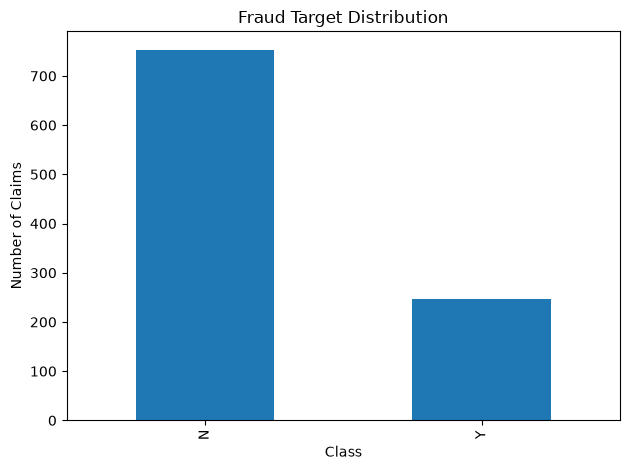

In [12]:
if target is not None:
    df[target].value_counts(dropna=False).plot(kind='bar')
    plt.title('Fraud Target Distribution')
    plt.xlabel('Class')
    plt.ylabel('Number of Claims')
    plt.tight_layout()
    plt.show()


In [14]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
if numeric_cols:
    display(df[numeric_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
months_as_customer,1000.0,2.039540e+02,1.151132e+02,0.00,115.7500,199.5,276.250,479.00
age,1000.0,3.894800e+01,9.140287e+00,19.00,32.0000,38.0,44.000,64.00
policy_number,1000.0,5.462386e+05,2.570630e+05,100804.00,335980.2500,533135.0,759099.750,999435.00
policy_deductable,1000.0,1.136000e+03,6.118647e+02,500.00,500.0000,1000.0,2000.000,2000.00
policy_annual_premium,1000.0,1.256406e+03,2.441674e+02,433.33,1089.6075,1257.2,1415.695,2047.59
umbrella_limit,1000.0,1.101000e+06,2.297407e+06,-1000000.00,0.0000,0.0,0.000,10000000.00
insured_zip,1000.0,5.012145e+05,7.170161e+04,430104.00,448404.5000,466445.5,603251.000,620962.00
capital-gains,1000.0,2.512610e+04,2.787219e+04,0.00,0.0000,0.0,51025.000,100500.00
capital-loss,1000.0,-2.679370e+04,2.810410e+04,-111100.00,-51500.0000,-23250.0,0.000,0.00
incident_hour_of_the_day,1000.0,1.164400e+01,6.951373e+00,0.00,6.0000,12.0,17.000,23.00


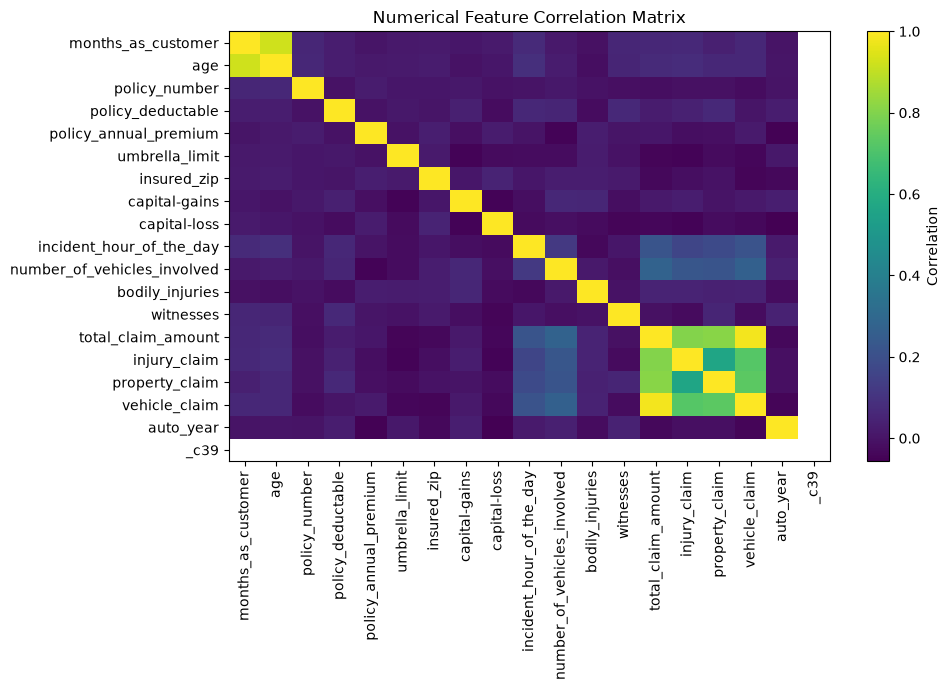

In [15]:
# Correlation matrix for numerical variables
if len(numeric_cols) >= 2:
    corr = df[numeric_cols].corr(numeric_only=True)
    plt.figure(figsize=(10, 7))
    plt.imshow(corr, aspect='auto')
    plt.colorbar(label='Correlation')
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title('Numerical Feature Correlation Matrix')
    plt.tight_layout()
    plt.show()


## 6. Preprocessing and model training

In [16]:
if target is None:
    raise ValueError('Set the correct target column name in the `target` variable before running the modeling section.')

model_df = df.dropna(subset=[target]).copy()
X = model_df.drop(columns=[target])
y = model_df[target]

# Remove obvious identifier-like columns that should not be predictive.
id_cols = [c for c in X.columns if any(k in c.lower() for k in ['policy_number', 'policy_id', 'claim_number', 'customer_id', 'incident_id'])]
X = X.drop(columns=id_cols, errors='ignore')

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
categorical_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features)
])

model = LogisticRegression(max_iter=2000, class_weight='balanced')
pipeline = Pipeline([('preprocessor', preprocessor), ('model', model)])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print('Model training completed.')


Model training completed.


In [17]:
print('Accuracy :', round(accuracy_score(y_test, y_pred), 4))
print('Precision:', round(precision_score(y_test, y_pred, average='weighted', zero_division=0), 4))
print('Recall   :', round(recall_score(y_test, y_pred, average='weighted', zero_division=0), 4))
print('F1-score :', round(f1_score(y_test, y_pred, average='weighted', zero_division=0), 4))
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred, zero_division=0))


Accuracy : 0.825
Precision: 0.8262
Recall   : 0.825
F1-score : 0.8256

Classification Report:

              precision    recall  f1-score   support

           N       0.89      0.88      0.88       151
           Y       0.64      0.65      0.65        49

    accuracy                           0.82       200
   macro avg       0.76      0.77      0.77       200
weighted avg       0.83      0.82      0.83       200



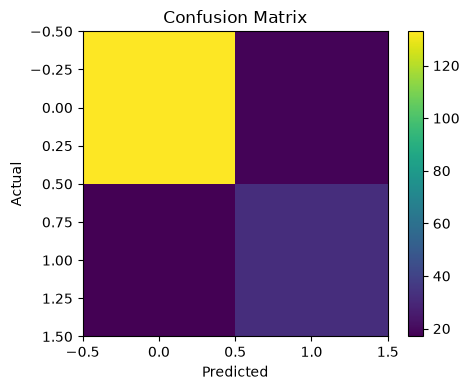

In [18]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.colorbar()
plt.tight_layout()
plt.show()


## 7. Conclusion

The project demonstrates an end-to-end data analytics workflow for insurance-claim fraud analysis. It covers data inspection, cleaning, exploratory analysis, feature preprocessing, classification, and evaluation. The workflow can be extended with additional models, feature engineering, hyperparameter tuning, and dashboard development in Tableau or IBM Watson Studio.

## 8. Technologies Used
- Python
- Jupyter Notebook
- Pandas and NumPy
- Matplotlib
- Scikit-learn
- IBM Watson Studio / Data Refinery (for data preparation and exploration)
- Tableau / SQL / spreadsheet tools can be used for complementary analysis and visualization.
